In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import folium
from folium.plugins import HeatMap
import numpy as np


In [12]:
# Load similarity scores (Adjust filenames as necessary)
jaccard_df = pd.read_csv("../Task 6 - Tika-Similarity/tika-files/Jaccard/jaccard_scores.csv")  # Jaccard similarity scores
edit_df = pd.read_csv("../Task 6 - Tika-Similarity/tika-files/Edit_distance/edit_scores.csv")  # Edit distance scores
cosine_df = pd.read_csv("../Task 6 - Tika-Similarity/tika-files/Cosine/cosine_scores.csv")  # Edit distance scores

In [16]:
# ### 1. Cluster Size Distribution (Bar Chart)
# def plot_cluster_size_distribution(cluster_df, title="Cluster Size Distribution"):
#     cluster_counts = cluster_df["Similarity_score"].value_counts()
#     plt.figure(figsize=(10, 5))
#     sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Blues_r")
#     plt.xlabel("Cluster ID")
#     plt.ylabel("Number of Haunted Places")
#     plt.title(title)
#     plt.xticks(rotation=45)
#     plt.show()

# plot_cluster_size_distribution(jaccard_df, "Jaccard Cluster Size Distribution")
# plot_cluster_size_distribution(edit_df, "Edit Distance Cluster Size Distribution")




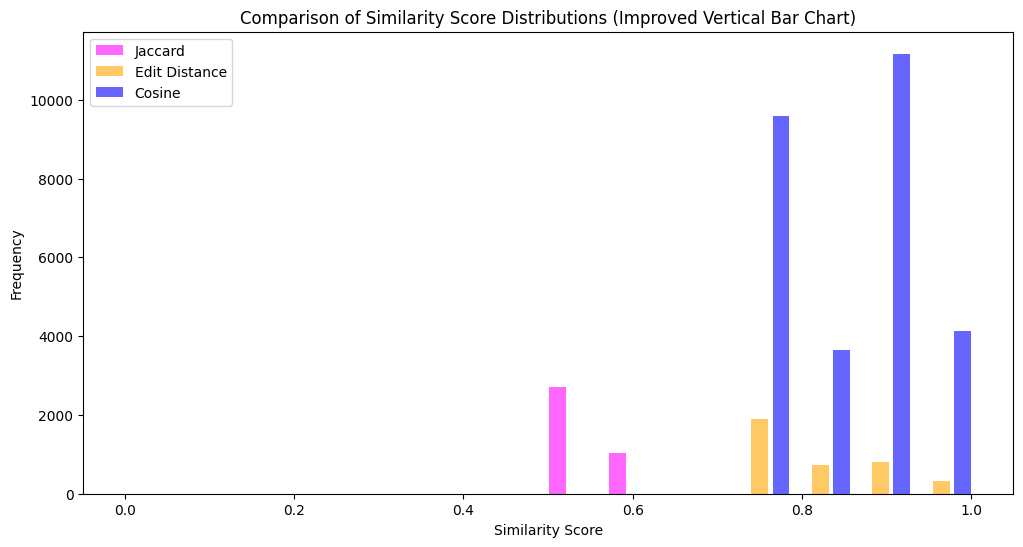

In [33]:
def plot_spaced_vertical_similarity_bars(jaccard_df, edit_df, cosine_df):
    plt.figure(figsize=(12, 6))

    # Define bins for uniform alignment
    bins = np.linspace(0, 1, 15)  # Fewer bins for better readability

    # Create histograms but store frequency counts to use as bars
    jaccard_counts, bin_edges = np.histogram(jaccard_df["Similarity_score"], bins=bins)
    edit_counts, _ = np.histogram(edit_df["Similarity_score"], bins=bins)
    cosine_counts, _ = np.histogram(cosine_df["Similarity_score"], bins=bins)

    # Calculate bin centers for positioning the bars
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Define bar width and spacing
    bar_width = 0.02  # Makes bars thinner for readability
    spacing = 0.025  # Space between different similarity methods

    # Create vertical bars with spacing
    plt.bar(bin_centers - spacing, jaccard_counts, width=bar_width, color="magenta", label="Jaccard", alpha=0.6)
    plt.bar(bin_centers, edit_counts, width=bar_width, color="orange", label="Edit Distance", alpha=0.6)
    plt.bar(bin_centers + spacing, cosine_counts, width=bar_width, color="blue", label="Cosine", alpha=0.6)

    # Labels and title
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.title("Comparison of Similarity Score Distributions (Improved Vertical Bar Chart)")
    plt.legend()
    plt.show()

plot_spaced_vertical_similarity_bars(jaccard_df, edit_df, cosine_df)


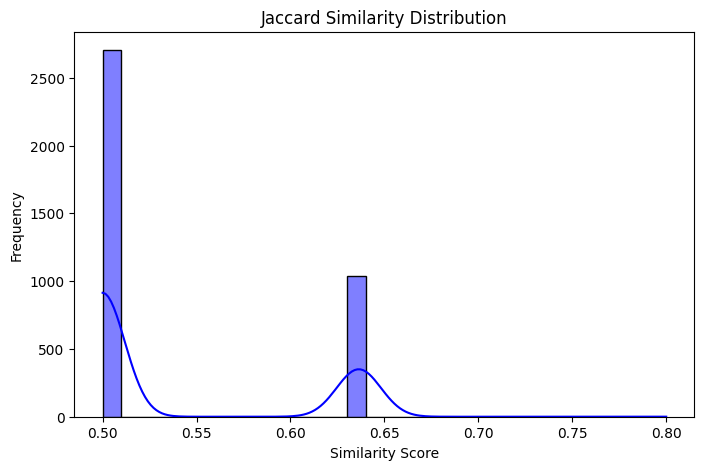

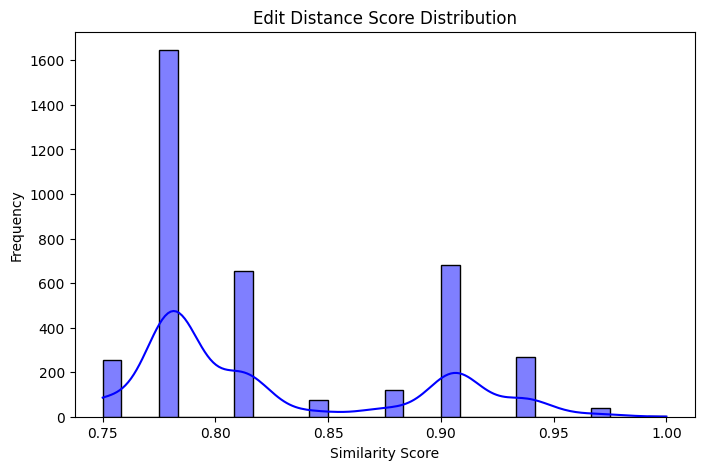

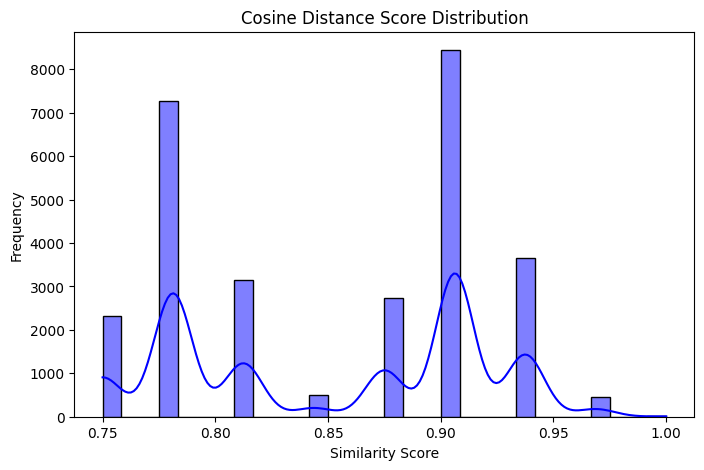

In [17]:
### 2. Similarity Score Distributions (Histogram)
def plot_similarity_distribution(df, column, title="Similarity Score Distribution"):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=30, kde=True, color="blue")
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

plot_similarity_distribution(jaccard_df, "Similarity_score", "Jaccard Similarity Distribution")
plot_similarity_distribution(edit_df, "Similarity_score", "Edit Distance Score Distribution")
plot_similarity_distribution(cosine_df, "Similarity_score", "Cosine Distance Score Distribution")

In [17]:
# ### 3. Word Cloud of Common Terms in Clusters
# def generate_wordcloud(cluster_df, title="Word Cloud of Haunted Place Descriptions"):
#     text = " ".join(cluster_df["description"])  # Assuming 'description' column exists
#     wordcloud = WordCloud(width=800, height=400, background_color="black").generate(text)

#     plt.figure(figsize=(10, 5))
#     plt.imshow(wordcloud, interpolation="bilinear")
#     plt.axis("off")
#     plt.title(title)
#     plt.show()

# generate_wordcloud(jaccard_clusters, "Jaccard Cluster Word Cloud")
# generate_wordcloud(edit_clusters, "Edit Distance Cluster Word Cloud")


# ### 4. Cluster Composition Pie Chart
# def plot_cluster_pie_chart(cluster_df, title="Cluster Composition"):
#     cluster_counts = cluster_df["cluster"].value_counts()
#     plt.figure(figsize=(8, 8))
#     plt.pie(cluster_counts, labels=cluster_counts.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
#     plt.title(title)
#     plt.show()

# plot_cluster_pie_chart(jaccard_clusters, "Jaccard Cluster Composition")
# plot_cluster_pie_chart(edit_clusters, "Edit Distance Cluster Composition")

In [19]:
# Load dataset (adjust file path if necessary)
df = pd.read_csv("../data/final_haunted_places (1).tsv", sep="\t")


In [60]:
df['Apparition Type']

0                 Ghost (Male)
1               Unknown (Male)
2                 Ghost (Male)
3                 Other (Male)
4                 Ghost (Male)
                 ...          
10987           Unknown (Male)
10988             Ghost (Male)
10989             Ghost (Male)
10990    Ghost (Male, teacher)
10991             Ghost (Male)
Name: Apparition Type, Length: 10992, dtype: object

/var/folders/z5/vfx1x7n1717bc2w84z8xwftw0000gn/T/ipykernel_17176/518895847.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette="Blues_r")


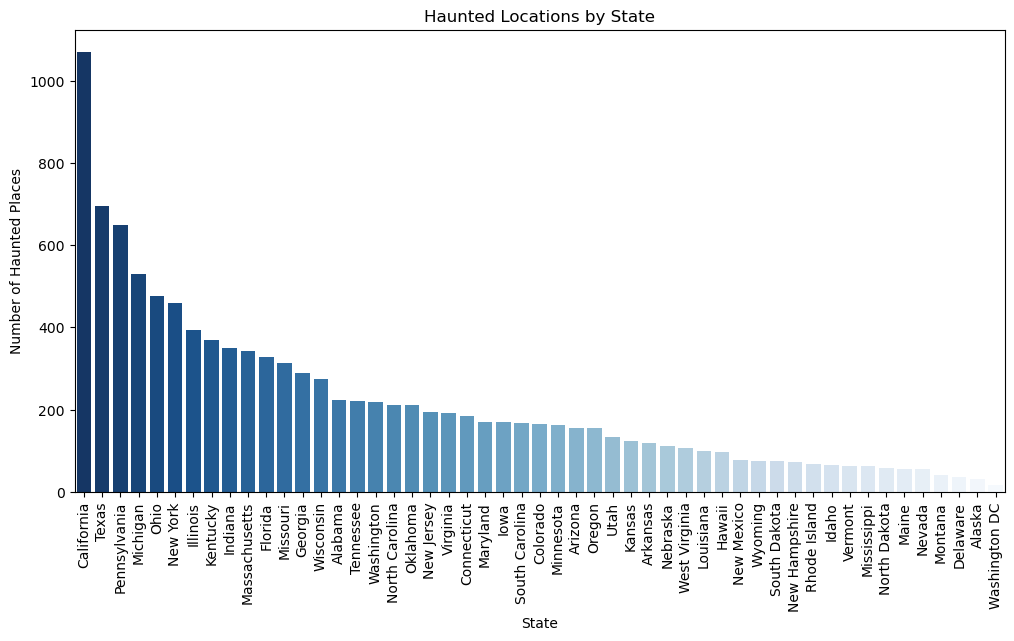

In [22]:
### 1. Haunted Locations by State (Bar Chart)
def plot_haunted_by_state():
    state_counts = df["state_abbrev"].value_counts()
    plt.figure(figsize=(12, 6))
    sns.barplot(x=state_counts.index, y=state_counts.values, palette="Blues_r")
    plt.xlabel("State")
    plt.ylabel("Number of Haunted Places")
    plt.title("Haunted Locations by State")
    plt.xticks(rotation=90)
    plt.show()

plot_haunted_by_state()


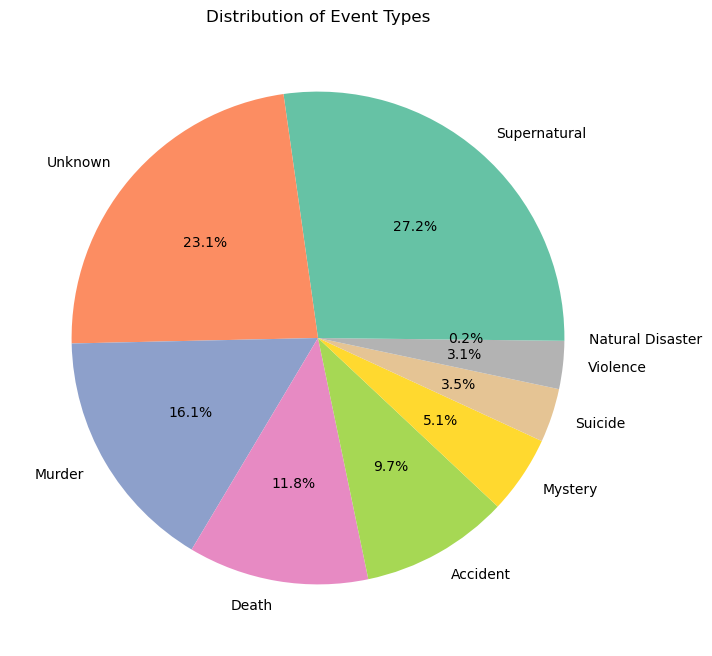

In [26]:
### 2. Type of Hauntings (Pie Chart)
def plot_haunting_types():
    if "Event Type" in df.columns:
        haunting_counts = df["Event Type"].value_counts()
        plt.figure(figsize=(8, 8))
        plt.pie(haunting_counts, labels=haunting_counts.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
        plt.title("Distribution of Event Types")
        plt.show()
    else:
        print("Column 'Event Type' not found in dataset.")

plot_haunting_types()


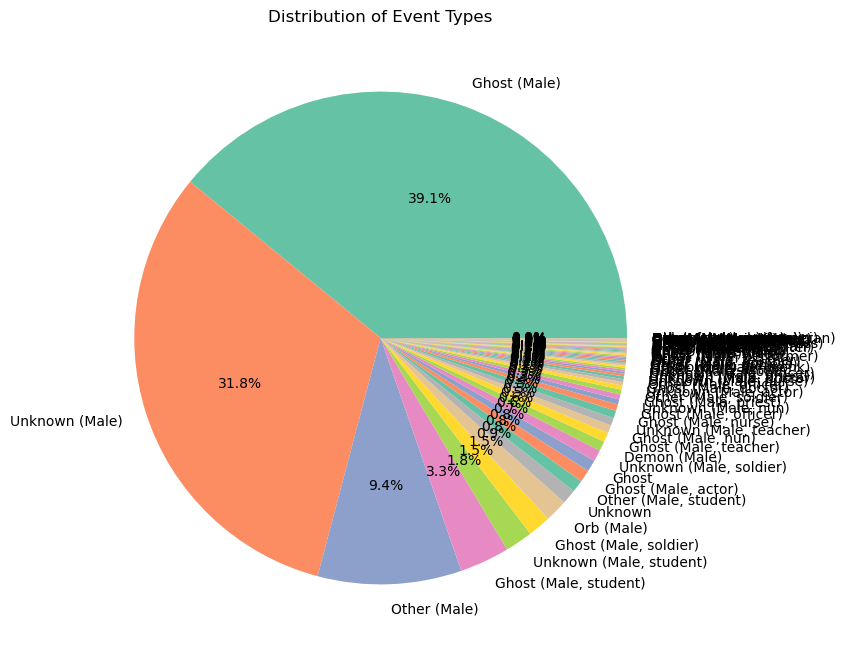

In [61]:
### 2.5. Type of Hauntings (Pie Chart)
def plot_haunting_types():
    if "Apparition Type" in df.columns:
        haunting_counts = df["Apparition Type"].value_counts()
        plt.figure(figsize=(8, 8))
        plt.pie(haunting_counts, labels=haunting_counts.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
        plt.title("Distribution of Event Types")
        plt.show()
    else:
        print("Column 'Event Type' not found in dataset.")

plot_haunting_types()


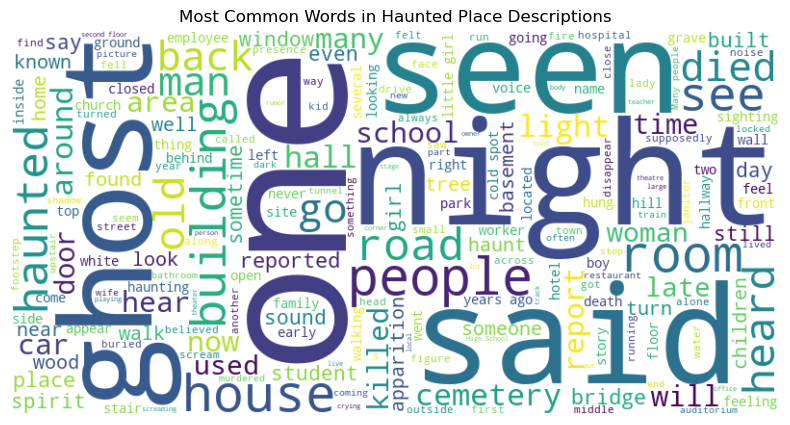

In [32]:
### 4. Word Frequency in Haunted Place Descriptions (Word Cloud)
def generate_wordcloud():
    text = " ".join(df["description"].dropna())  # Assuming 'Description' column exists
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Most Common Words in Haunted Place Descriptions")
    plt.show()

generate_wordcloud()


In [33]:
### 5. Average Age of Hauntings (Box Plot)
def plot_age_of_hauntings():
    if "Year Built" in df.columns:
        df["Age"] = 2025 - df["Year Built"]
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=df["Age"])
        plt.xlabel("Years Since Built")
        plt.title("Age Distribution of Haunted Places")
        plt.show()
    else:
        print("Column 'Year Built' not found in dataset.")

plot_age_of_hauntings()

Column 'Year Built' not found in dataset.


In [41]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')
alcohol_df = pd.read_csv('../data/alcohol_abuse_by_state.csv')

haunted_places = haunted_places.rename(columns={'state': 'State'})
combined_df = haunted_places.merge(alcohol_df, on='State', how='left')

In [43]:
# Standardize state names by stripping spaces to avoid merge issues
haunted_places["State"] = haunted_places["State"].str.strip()
alcohol_df["State"] = alcohol_df["State"].str.strip()

# Aggregate haunted places by state (count occurrences of each state)
haunted_count = haunted_places.groupby("State").size().reset_index(name="Haunted Place Count")

# Ensure "Haunted Place Count" exists in alcohol_df (set default 0)
alcohol_df["Haunted Place Count"] = 0  

# Merge the new count into the Alcohol Abuse dataset
alcohol_df = alcohol_df.merge(haunted_count, on="State", how="left", suffixes=("", "_new"))

# Replace the 0s with actual values from the merged data
alcohol_df["Haunted Place Count"] = alcohol_df["Haunted Place Count_new"].fillna(0).astype(int)

# Drop the temporary "_new" column used during merging
alcohol_df = alcohol_df.drop(columns=["Haunted Place Count_new"])


In [44]:
alcohol_df

,State,Deaths per Year,Average Potential Life Years Lost per Death,"Deaths per 10,000 Adults",Percentage of Adults who Binge Drink 1+ Times per Month,Median Drinks per Binge,Top 25% Drinks per Binge,Median Binge per Month,Top 25% Binge per Month,Increase in Alcohol Deaths per Capita from 2015 to 2019,Male Proportion of Deaths,Percent Deaths from Chronic Causes,Percent Deaths from Acute Causes,Percent Deaths 35+,Percent Deaths under 21,Years of Life Lost per Year,Taxpayer Cost in 2010 (billions),Inflation Adjusted Cost to 2022 (billions),Inflation Adjusted Per Drink (2022),Haunted Place Count
0,Alabama,"2,208",27.0,6.06,13.6%,5.5,7.2,1.7,4.0,44.8%,71.5%,49.8%,50.2%,79.9%,3.94%,59606,3.7240,5.0280,3.06,224
1,Alaska,433,30.7,7.83,16.0%,5.4,7.1,1.9,4.4,45.0%,65.4%,52.4%,47.6%,77.1%,3.93%,13285,0.8272,1.1700,3.04,32
2,Arizona,"3,670",25.8,6.62,16.7%,5.5,7.9,1.5,3.8,40.9%,68.3%,59.2%,40.8%,84.1%,2.75%,94686,5.9460,8.0280,2.27,156
3,Arkansas,"1,407",25.5,6.08,16.0%,5.6,9.2,1.9,4.5,52.1%,69.8%,55.7%,44.3%,83.4%,3.55%,35826,2.0730,2.7990,3.06,119
4,California,"15,443",24.4,5.04,16.6%,5.5,7.7,1.6,3.7,40.0%,69.1%,64.4%,35.6%,86.1%,2.49%,376899,35.0110,47.2640,3.29,1070
5,Colorado,"2,623",27.2,5.82,19.8%,5.6,7.6,1.6,3.7,45.4%,67.7%,61.3%,38.7%,83.1%,2.78%,71300,5.0570,6.8260,2.89,166
6,Connecticut,"1,426",25.4,4.97,18.7%,5.2,6.5,1.6,3.5,55.3%,68.2%,55.2%,44.8%,84.9%,2.17%,36201,3.0290,4.0890,2.75,185
7,Delaware,466,26.9,5.95,18.3%,5.3,7.3,1.7,4.4,65.3%,70.2%,53.6%,46.4%,81.3%,2.79%,12543,0.8038,1.0850,2.21,37
8,District of Columbia,392,26.7,6.95,22.5%,5.2,6.7,1.5,3.4,82.9%,67.6%,53.3%,46.7%,82.1%,3.32%,10473,0.9184,1.2400,2.89,0
9,Florida,"10,655",24.0,6.16,17.5%,5.5,7.3,1.8,4.9,54.0%,69.2%,60.8%,39.2%,85.9%,2.34%,255673,15.3220,20.6850,2.46,328


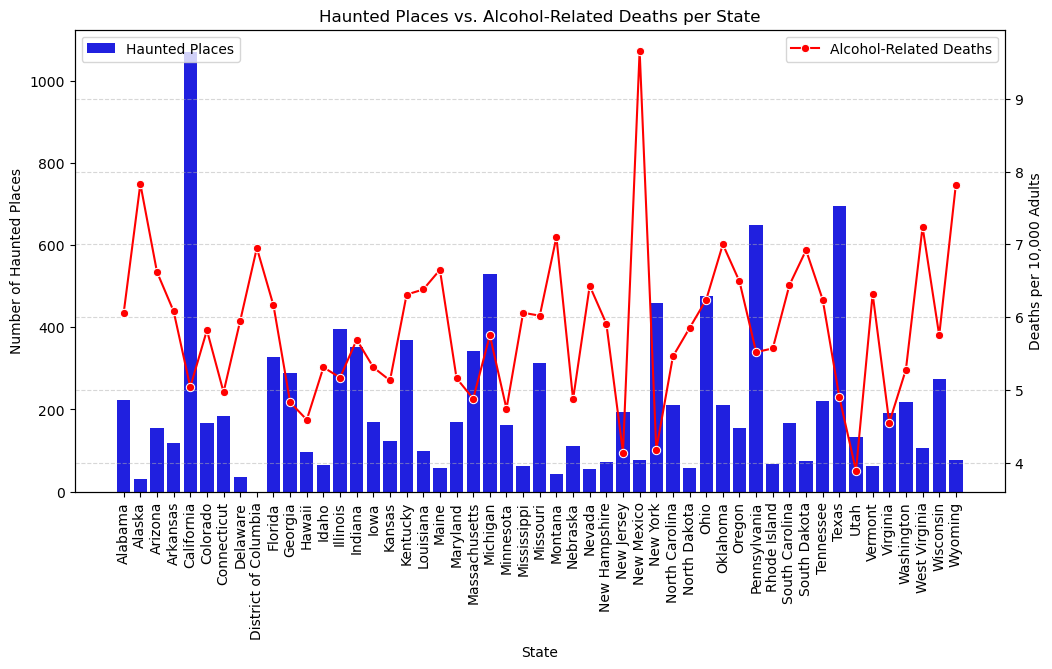

In [45]:
plt.figure(figsize=(12, 6))

# Create the bar chart for Haunted Places
ax = sns.barplot(x=alcohol_df["State"], y=alcohol_df["Haunted Place Count"], color="blue", label="Haunted Places")

# Create a secondary axis for Alcohol-Related Deaths
ax2 = ax.twinx()
sns.lineplot(x=alcohol_df["State"], y=alcohol_df["Deaths per 10,000 Adults"],
             ax=ax2, color="red", label="Alcohol-Related Deaths", marker="o")

# Set labels
ax.set_xlabel("State")
ax.set_ylabel("Number of Haunted Places")
ax2.set_ylabel("Deaths per 10,000 Adults")

# Fix the issue by setting ticks before labels
ax.set_xticks(range(len(alcohol_df["State"])))
ax.set_xticklabels(alcohol_df["State"], rotation=90)

# Legends and title
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Haunted Places vs. Alcohol-Related Deaths per State")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()
